[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/12_deeptab/44_deeptab_tabular_deep_learning.ipynb)

> 📎 **Optional module — reference style.** Module 12 is optional. Like the appendices, this notebook is written as a demo / reference: it focuses on *seeing* a library at work rather than interactive exercises. It is built to run end-to-end *without* the optional library — it falls back to a small built-in stand-in — so you can read and run it offline. Install the optional library (see **Install** below) to swap the stand-in for the real thing.

---

# 📓 Notebook 44 — DeepTab: Deep Learning for Tabular Data

> **Module:** 12 · Optional · **Type:** Reference · **Estimated time:** 60–90 min · **Difficulty:** Intermediate → Advanced

For two decades, structured/tabular data — the spreadsheets, transaction logs, and feature stores that run most of a business — has belonged to **gradient-boosted trees** (XGBoost, LightGBM, CatBoost). On the median tabular benchmark they are still the thing to beat: fast, robust, almost hyperparameter-forgiving.

But the gap has narrowed. A wave of architectures designed *specifically for tables* — **FT-Transformer**, **SAINT**, **NODE**, **TabM**, **ResNet**, and sequence models such as **Mamba** — now match or beat boosting on large, complex datasets, and they unlock things trees simply cannot do natively:

- **Distributional regression** — predict an entire probability distribution (mean *and* variance, or a Poisson/Gamma), not just a point estimate. Gold for pricing, risk, and inventory.
- **Latent embeddings** — learn dense vector representations of each row that you can reuse downstream (similarity search, clustering, feeding another model).
- **End-to-end multimodal** — fuse tabular columns with text or image towers in a single differentiable model.
- **Transfer learning** — pre-train on one table, fine-tune on another.

**[DeepTab](https://github.com/OpenTabular/DeepTab)** (from the OpenTabular project) wraps **15** stable models (plus a few experimental ones) behind a single, clean scikit-learn `BaseEstimator` API. Every architecture ships as a matching `<Name>Classifier`, `<Name>Regressor`, and `<Name>LSS` (distributional) trio — so switching from a Transformer to Mamba to a plain MLP is a one-line change of class name.

> 🧭 **Mental model we'll use throughout — *one socket, many power tools*.** Think of the scikit-learn `.fit` / `.predict` interface as a single wall **socket**. The gradient-boosted tree is the **trusty cordless drill** already in your hand — grab it first, it handles most jobs. DeepTab's 15 architectures (Mamba, FT-Transformer, SAINT, NODE…) are **specialist power tools** that plug into the *same socket*: swapping one for another is just changing which tool you grab, not rewiring the wall. The whole notebook is about *which tool fits the job* — and the discipline of not reaching for the heavy specialist when the drill already finished the work.

**Our running example.** One concrete table runs through every section: a **customer-churn** frame — tenure, monthly charges, support tickets, contract type, region — the kind of mixed-type business table you actually model. We'll predict churn, predict revenue, get an uncertainty band, and pull row embeddings from it, all by plugging different tools into the same socket.

## 🎯 Learning objectives

By the end you will be able to:

1. Decide **when** a tabular deep-learning model is worth it versus reaching for a gradient-boosted tree (spoiler: try the trees first).
2. Train a **classifier** and a **regressor** with DeepTab's sklearn-style `.fit` / `.predict` / `.predict_proba` API, and swap architectures by name.
3. Use **distributional regression (LSS)** to predict full distributions and reason about uncertainty for risk and pricing.
4. Extract **latent embeddings** with `.encode()` and feed them to a downstream model.
5. **Tune** hyperparameters with both DeepTab's built-in `optimize_hparams` and sklearn's `RandomizedSearchCV`.

## ✅ Prerequisites

- **NB 17 — scikit-learn basics**: the `fit` / `predict` estimator pattern, train/test splits, metrics.
- **NB 19 — feature engineering**: numeric vs categorical columns, encoding, why preprocessing matters.
- **NB 4 appendix A1–A3 — PyTorch foundations**: tensors, the training loop, epochs and learning rates (DeepTab is built on PyTorch + Lightning, so these terms recur).

## 📦 Install

```bash
pip install deeptab
```

> ⚠️ **Heads-up:** `deeptab` pulls in **PyTorch** and **PyTorch Lightning**, which are large downloads (hundreds of MB) and may need a CUDA-matched build for GPU. That is exactly why this notebook is **offline-first**: if `deeptab` is not installed, every cell falls back to a lightweight scikit-learn stand-in so you can read and run the whole thing right now.

## 🧰 Setup & imports

Standard scientific Python stack. Nothing here is downloaded — the dataset is synthetic and generated inline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    mean_absolute_error, r2_score,
)
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.base import BaseEstimator

from scipy.stats import randint, norm

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
print("Imports OK — versions:")
print("  numpy   ", np.__version__)
print("  pandas  ", pd.__version__)

Imports OK — versions:
  numpy    2.4.6
  pandas   3.0.3


## 🔌 Smoke test: is DeepTab installed?

This is the gate the whole notebook hangs on. We try to import `deeptab` and set a single flag, `HAS_DEEPTAB`. Every later cell branches on it:

- `HAS_DEEPTAB == True` → use the **real** DeepTab models.
- `HAS_DEEPTAB == False` → use a **scikit-learn stand-in** that mimics the same `.fit` / `.predict` / `.predict_proba` / `.encode` calls.

The stand-in is *not* a DeepTab implementation — it is a teaching scaffold so the API shape and the surrounding analysis still run offline.

In [2]:
try:
    import deeptab
    from deeptab.models import (
        MambularClassifier, MambularRegressor, MambularLSS,
    )
    # DeepTab v2 configures every model through three small objects instead of
    # one long kwargs list: architecture (MambularConfig), input preprocessing
    # (PreprocessingConfig) and the training loop (TrainerConfig). This import
    # fails on a pre-2.0 install, so HAS_DEEPTAB also gates on v2+.
    from deeptab.configs import (
        MambularConfig, PreprocessingConfig, TrainerConfig,
    )
    HAS_DEEPTAB = True
    print(f'✅ DeepTab {getattr(deeptab, "__version__", "?")} found — using real models.')
except Exception as exc:  # ImportError, or a pre-2.0 install without deeptab.configs
    HAS_DEEPTAB = False
    print("ℹ️  DeepTab (>=2.0) not installed — running with the offline sklearn stand-in.")
    print(f"   (import said: {type(exc).__name__})")
    print("   Install with:  pip install deeptab")

ℹ️  DeepTab (>=2.0) not installed — running with the offline sklearn stand-in.
   (import said: ModuleNotFoundError)
   Install with:  pip install deeptab


### The offline stand-in

When DeepTab is missing we define drop-in classes with the **same constructor and methods** as DeepTab v2's estimators. Internally they are ordinary scikit-learn models:

- classifier / regressor → an `MLPClassifier` / `MLPRegressor` (a real, if small, neural net) sitting behind an ordinal encoder for the categorical columns;
- `.encode(X)` → returns the last hidden-layer activations as a cheap 'embedding';
- `MambularLSS` → fits the mean with an MLP and estimates a constant residual standard deviation, then returns per-row `(mean, std)` to mirror a distributional head.

DeepTab v2 configures a model through **three small objects** — `MambularConfig` (architecture), `PreprocessingConfig` (input handling) and `TrainerConfig` (the training loop) — instead of one long list of keyword arguments. So the stand-ins take the *same* `model_config=` / `preprocessing_config=` constructor and read the width/depth (`d_model`, `n_layers`) off the config; DL-only settings (`numerical_preprocessing`, `dropout`, `lr`, `family`, ...) are accepted for parity and otherwise ignored. They subclass scikit-learn's `BaseEstimator`, so `get_params` / `set_params` — and therefore `RandomizedSearchCV` with nested `model_config__d_model` params — behave exactly like the real thing. Read the bodies once; after that, treat them as DeepTab.

In [3]:
from dataclasses import dataclass
from typing import Optional

from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------------------------
# Offline stand-in config objects — mirror DeepTab v2's split-config API
# ---------------------------------------------------------------------------
# DeepTab v2 configures a model through three objects (architecture /
# preprocessing / training) rather than one flat kwargs list. When the real
# library is absent we define name-compatible stand-ins so the *exact same*
# calling code works in both modes. They subclass sklearn's BaseEstimator, so
# get_params / set_params — and therefore RandomizedSearchCV with nested
# `model_config__d_model` params — behave just like the real configs. Only the
# few fields this notebook touches are modelled; the real configs expose many.
if not HAS_DEEPTAB:
    @dataclass
    class MambularConfig(BaseEstimator):
        d_model: int = 64
        n_layers: int = 4
        dropout: float = 0.1

    @dataclass
    class PreprocessingConfig(BaseEstimator):
        numerical_preprocessing: Optional[str] = None
        n_bins: Optional[int] = None

    @dataclass
    class TrainerConfig(BaseEstimator):
        max_epochs: int = 100
        lr: float = 1e-4
        patience: int = 15

# String/categorical dtypes, named explicitly. Under pandas 3.x a plain string
# column carries the new 'str' dtype, so we list 'string' alongside 'object'
# and 'category' to catch every text column WITHOUT the backward-compat warning
# that `include=['object', ...]` alone would raise.
_CAT_DTYPES = ["object", "string", "category"]

def _fit_ordinal_encoder(X):
    """Fit an OrdinalEncoder on the categorical columns of a *training* frame.
    Returns (cat_cols, fitted_encoder). Fitting on train and reusing on test is
    the no-leakage discipline from NB 19: a fresh per-frame fit could map the
    same category to different integer codes in train vs test."""
    cat_cols = X.select_dtypes(include=_CAT_DTYPES).columns
    enc = None
    if len(cat_cols):
        enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        enc.fit(X[cat_cols].astype(str))
    return cat_cols, enc

def _apply_ordinal_encoder(X, cat_cols, enc):
    """Transform categoricals to ints with a *previously fitted* encoder."""
    X = X.copy()
    if len(cat_cols):
        X[cat_cols] = enc.transform(X[cat_cols].astype(str))
    return X.to_numpy(dtype=float)


# Shared net settings for the stand-in MLPs. early_stopping + n_iter_no_change
# is literally a 'patience' early-stop on a held-out validation slice -- it
# mirrors DeepTab's `patience`, reaches a good fit, and avoids the spurious
# 'did not converge' warning you'd get from a hard max_iter cut-off.
_MLP_KW = dict(max_iter=1500, early_stopping=True, n_iter_no_change=40,
               random_state=RANDOM_STATE)


class _StandInBase(BaseEstimator):
    """Mimics DeepTab v2's estimator surface on top of a scikit-learn MLP.

    Takes the same split-config constructor as the real estimators
    (`model_config` / `preprocessing_config` / `trainer_config`) and reads the
    width/depth off `model_config`. DL-only settings (preprocessing strategy,
    dropout, lr, ...) are accepted for parity and otherwise ignored — the MLP
    scales features and trains to scikit-learn's own convergence."""
    # NOTE: params are stored verbatim (no renaming, no **kwargs) so sklearn
    # get_params/set_params/clone — and nested `model_config__d_model` tuning —
    # work out of the box.
    def __init__(self, model_config=None, preprocessing_config=None,
                 trainer_config=None, random_state=RANDOM_STATE):
        self.model_config = model_config
        self.preprocessing_config = preprocessing_config
        self.trainer_config = trainer_config
        self.random_state = random_state

    def _arch(self):
        return self.model_config if self.model_config is not None else MambularConfig()

    def _hidden(self):
        # map model_config depth/width onto an MLP geometry, capped for speed
        cfg = self._arch()
        width = min(cfg.d_model, 64)
        depth = min(cfg.n_layers, 3)
        return tuple([width] * max(depth, 1))

    def _build_net(self):
        raise NotImplementedError

    # --- preprocessing: encoder + scaler fit ONCE on train, reused on test ---
    def _prep_fit(self, X):
        self._cat_cols, self._enc = _fit_ordinal_encoder(X)
        Xnum = _apply_ordinal_encoder(X, self._cat_cols, self._enc)
        # Scaling matters: unscaled columns (charges ~40-115 vs codes 0-3) make
        # the net's optimiser crawl and never converge. This is also what the
        # real model's numerical_preprocessing does for us.
        self._scaler = StandardScaler().fit(Xnum)
        return self._scaler.transform(Xnum)

    def _prep(self, X):
        Xnum = _apply_ordinal_encoder(X, self._cat_cols, self._enc)
        return self._scaler.transform(Xnum)

    def fit(self, X, y, max_epochs=100, lr=1e-3, patience=10, **kw):
        self.net_ = self._build_net()   # built here so set_params is respected
        self.net_.fit(self._prep_fit(X), y)
        return self

    def predict(self, X):
        return self.net_.predict(self._prep(X))

    def encode(self, X):
        """Last-hidden-layer activations as a stand-in embedding."""
        a = self._prep(X)
        # forward-propagate manually through the fitted MLP up to last hidden layer
        for w, b in zip(self.net_.coefs_[:-1], self.net_.intercepts_[:-1]):
            a = np.maximum(0.0, a @ w + b)  # relu
        return a

    def optimize_hparams(self, X, y, **kw):
        # No real search offline. Mirror DeepTab v2's contract: report the
        # current config as the 'best' and RETURN a list of hparams (the real
        # tuner mutates self.config and returns the winning point). The caller
        # refits afterwards.
        cfg = self._arch()
        print("   [stand-in] optimize_hparams is a no-op (no real search).")
        return [cfg.d_model, cfg.n_layers]


class StandInClassifier(_StandInBase):
    def _build_net(self):
        return MLPClassifier(hidden_layer_sizes=self._hidden(), **_MLP_KW)
    def predict_proba(self, X):
        return self.net_.predict_proba(self._prep(X))


class StandInRegressor(_StandInBase):
    def _build_net(self):
        return MLPRegressor(hidden_layer_sizes=self._hidden(), **_MLP_KW)


class StandInLSS(_StandInBase):
    """Distributional stand-in: MLP mean + constant residual sigma.

    Like DeepTab v2, the distribution `family` is a `.fit()` argument."""
    def _build_net(self):
        return MLPRegressor(hidden_layer_sizes=self._hidden(), **_MLP_KW)
    def fit(self, X, y, max_epochs=100, lr=1e-3, patience=10, family="normal", **kw):
        self.family_ = family
        self.net_ = self._build_net()
        Xs = self._prep_fit(X)
        self.net_.fit(Xs, y)
        resid = y - self.net_.predict(Xs)
        self.sigma_ = float(np.std(resid)) or 1.0
        return self
    def predict(self, X):
        """Return (mean, std) per row, mirroring a distributional head."""
        mu = self.net_.predict(self._prep(X))
        sd = np.full_like(mu, self.sigma_)
        return np.column_stack([mu, sd])

print("Stand-in classes defined.")

Stand-in classes defined.


### One factory, two backends

To keep later cells clean we wrap the choice in small factory functions. `make_classifier(...)` returns a real `MambularClassifier` when DeepTab is present, otherwise a `StandInClassifier`. Both take the **same split-config arguments** (`model_config=`, `preprocessing_config=`) and the same methods, so **the rest of the notebook never needs another `if HAS_DEEPTAB`** for basic fit/predict — it just calls the factory. (This *is* the socket from our mental model, in code: one shared plug, whatever tool is behind it.)

> 🔁 **Swapping architectures.** With real DeepTab, every model below has siblings — `FTTransformerClassifier`, `TabTransformerClassifier`, `ResNetClassifier`, `MLPClassifier`, `SAINTClassifier`, `TabMClassifier`, `NODEClassifier`, ... — each with a matching `<Name>Config`. To try a Transformer instead of Mamba you change the class name (and, if you tune it, its config class). Same socket, different power tool.

In [4]:
def make_classifier(model_config=None, preprocessing_config=None, **kw):
    cls = MambularClassifier if HAS_DEEPTAB else StandInClassifier
    return cls(model_config=model_config,
               preprocessing_config=preprocessing_config, **kw)

def make_regressor(model_config=None, preprocessing_config=None, **kw):
    cls = MambularRegressor if HAS_DEEPTAB else StandInRegressor
    return cls(model_config=model_config,
               preprocessing_config=preprocessing_config, **kw)

def make_lss(model_config=None, preprocessing_config=None, **kw):
    cls = MambularLSS if HAS_DEEPTAB else StandInLSS
    return cls(model_config=model_config,
               preprocessing_config=preprocessing_config, **kw)

backend = "real DeepTab" if HAS_DEEPTAB else "sklearn stand-in"
print(f"Model factory ready — backend: {backend}.")

Model factory ready — backend: sklearn stand-in.


## 1. The value proposition — and when *not* to use it

Before we plug in any specialist tool, the most important question: *do we even need one?* Let's be honest, because hype helps no one ship reliable models.

### Start with gradient boosting — the drill already in your hand

For a typical business table — tens of thousands of rows, a few dozen columns, a clear target — **XGBoost / LightGBM / `HistGradientBoosting` is your first call.** It trains in seconds, tolerates messy mixed-type data, rarely overfits catastrophically, and is hard to beat on accuracy per unit of effort. This is the cordless drill from our mental model: reach for it first. Deep learning for tables earns its keep only when one of the following is true:

| Reach for tabular DL when… | Because… |
|---|---|
| **You have a lot of data** (≫100k rows) | Neural nets keep improving with scale where trees plateau. |
| **You need a full distribution**, not a point | LSS heads give calibrated mean + variance for pricing, risk, demand. |
| **The problem is multimodal** (table + text/image) | One differentiable model can fuse towers end-to-end. |
| **You want reusable embeddings** | `.encode()` yields dense row vectors for search, clustering, or transfer. |
| **Transfer / pre-training helps** | Pre-train on a big related table, fine-tune on the small target one. |

If none of those apply, a boosted tree is probably the right — and cheaper — answer. The professional move is to **benchmark the tree baseline first** and only adopt DL if it clears that bar by a margin worth the extra complexity, compute, and GPU dependency. We keep a `HistGradientBoosting` baseline in this notebook for exactly that reason — the drill stays on the bench the whole time, so every specialist tool has something honest to beat.

## 2. A synthetic business dataset (churn)

Time to lay our running example on the workbench. We build a small **customer-churn** frame inline — no downloads. It mixes **numeric** columns (tenure, monthly charges, support tickets, usage) with **categorical** ones (contract type, payment method, region). This mirrors the kind of mixed-type table DeepTab is designed for, and lets us show that its **PreTab** preprocessing detects column types straight from a pandas `DataFrame`.

This one frame is the material every tool in the notebook works on — classifier, regressor, distributional head, and embedder all plug into the same socket and chew on *this* table. ~400 rows keeps everything fast — including real DeepTab on a CPU.

In [5]:
N = 400
# We use only the numeric FEATURE matrix from make_classification; the churn
# label is rebuilt below from a logit so the 'contract' column can be made
# genuinely informative (and the classes come out roughly balanced).
Xc, _ = make_classification(
    n_samples=N, n_features=6, n_informative=4, n_redundant=1,
    n_classes=2, class_sep=1.2, random_state=RANDOM_STATE,
)

df = pd.DataFrame({
    "tenure_months":   (np.abs(Xc[:, 0]) * 18 + 6).round().astype(int),
    "monthly_charges": (np.abs(Xc[:, 1]) * 25 + 40).round(2),
    "support_tickets": np.clip((Xc[:, 2] * 2 + 2).round(), 0, None).astype(int),
    "avg_usage_gb":    (np.abs(Xc[:, 3]) * 30 + 10).round(1),
    "contract": rng.choice(["month-to-month", "one-year", "two-year"],
                           size=N, p=[0.55, 0.30, 0.15]),
    "payment":  rng.choice(["card", "bank", "e-check"], size=N),
    "region":   rng.choice(["north", "south", "east", "west"], size=N),
})
# Make 'contract' genuinely informative: month-to-month churns more.
contract_risk = df["contract"].map({"month-to-month": 0.9,
                                     "one-year": 0.0, "two-year": -0.9}).to_numpy()
churn_logit = Xc[:, :4].sum(axis=1) * 0.5 + contract_risk + rng.normal(0, 0.4, N)
df["churn"] = (churn_logit > np.median(churn_logit) - 0.1).astype(int)

print(f"Shape: {df.shape} | churn rate: {df.churn.mean():.1%}")
df.head()

Shape: (400, 8) | churn rate: 52.8%


,tenure_months,monthly_charges,support_tickets,avg_usage_gb,contract,payment,region,churn
0,25,42.87,2,77.8,one-year,card,west,0
1,7,49.24,1,36.6,month-to-month,card,south,1
2,29,91.04,0,77.6,two-year,bank,west,0
3,18,45.69,1,60.0,one-year,e-check,west,1
4,29,65.16,0,68.6,month-to-month,e-check,east,0


Numeric   : ['tenure_months', 'monthly_charges', 'support_tickets', 'avg_usage_gb']
Categorical: ['contract', 'payment', 'region']


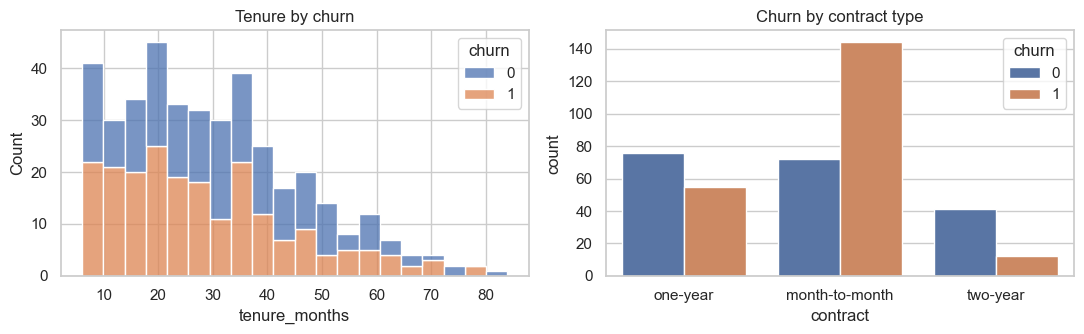

In [6]:
# Quick look at the type split PreTab would detect automatically.
num_cols = df.drop(columns="churn").select_dtypes("number").columns.tolist()
cat_cols = df.drop(columns="churn").select_dtypes(include=_CAT_DTYPES).columns.tolist()
print("Numeric   :", num_cols)
print("Categorical:", cat_cols)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(data=df, x="tenure_months", hue="churn", bins=20,
             ax=axes[0], multiple="stack")
axes[0].set_title("Tenure by churn")
sns.countplot(data=df, x="contract", hue="churn", ax=axes[1])
axes[1].set_title("Churn by contract type")
plt.tight_layout(); plt.show()

In [7]:
feature_cols = num_cols + cat_cols
X = df[feature_cols].copy()       # keep it a DataFrame — DeepTab wants that
y = df["churn"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE,
)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")
print(f"X dtype check — still a DataFrame? {isinstance(X_train, pd.DataFrame)}")

Train: (300, 7)  Test: (100, 7)
X dtype check — still a DataFrame? True


## 3. Classification with `MambularClassifier`

Now the headline. DeepTab's API is deliberately scikit-learn shaped, so if you know `.fit` / `.predict` / `.predict_proba`, you already know this. DeepTab **v2** groups settings into three config objects — architecture, preprocessing and training — so each concern is tuned independently:

```python
from deeptab.models import MambularClassifier
from deeptab.configs import MambularConfig, PreprocessingConfig

model = MambularClassifier(
    model_config=MambularConfig(
        d_model=64,        # width of the internal representation
        n_layers=4,        # depth (here, Mamba blocks)
    ),
    preprocessing_config=PreprocessingConfig(
        numerical_preprocessing='ple',  # piecewise-linear encoding of numerics
        n_bins=50,                      # bins for the PLE encoder
    ),
)
model.fit(X_train, y_train, max_epochs=150, lr=1e-4, patience=10)
preds = model.predict(X_test)
proba = model.predict_proba(X_test)
```

Where each knob lives in v2:

- **`MambularConfig`** — the *architecture*. `d_model` is the hidden width (bigger = more capacity); `n_layers` is depth (state-space blocks for Mamba, attention layers for `FTTransformer`); `dropout` regularises.
- **`PreprocessingConfig`** — how columns are encoded. `numerical_preprocessing='ple'` (piecewise-linear encoding) bins each numeric feature and learns per-bin slopes — a strong default that often beats plain `'standardization'`; `'quantile'`, `'box-cox'` and `'yeo-johnson'` are also available. `n_bins` sets the PLE resolution.
- **`TrainerConfig`** — optimiser/schedule settings (`lr`, `weight_decay`, `optimizer_type`, ...) when you want them pinned on the estimator. The everyday knobs **`max_epochs` / `lr` / `patience`** can also be passed straight to `.fit`, which is what we do below; `patience` drives early stopping.

Offline, the stand-in ignores `max_epochs`/`lr`/`patience` (it trains to scikit-learn's own convergence on scaled features); those knobs drive the *real* DeepTab model. We still thread `EPOCHS` through so the calling code is identical in both modes.

In [8]:
# Lighter settings keep the offline run snappy; bump these up with real DeepTab.
EPOCHS = 150 if HAS_DEEPTAB else 5

clf = make_classifier(
    model_config=MambularConfig(d_model=64, n_layers=4),
    preprocessing_config=PreprocessingConfig(numerical_preprocessing="ple", n_bins=50),
)
clf.fit(X_train, y_train, max_epochs=EPOCHS, lr=1e-4, patience=10)

pred = clf.predict(X_test)
_proba = np.asarray(clf.predict_proba(X_test))
# Both backends return a 2-column (P_stay, P_churn) array for binary tasks
# in v2; we still coerce defensively so a 1-column head wouldn't break this.
proba = _proba[:, 1] if _proba.ndim == 2 and _proba.shape[1] > 1 else _proba.ravel()

print(f"Backend : {backend}")
print(f"Accuracy: {accuracy_score(y_test, pred):.3f}")
print(f"ROC-AUC : {roc_auc_score(y_test, proba):.3f}")
print()
print(classification_report(y_test, pred, target_names=["stay", "churn"]))

Backend : sklearn stand-in
Accuracy: 0.780
ROC-AUC : 0.848

              precision    recall  f1-score   support

        stay       0.84      0.66      0.74        47
       churn       0.75      0.89      0.81        53

    accuracy                           0.78       100
   macro avg       0.79      0.77      0.77       100
weighted avg       0.79      0.78      0.78       100



### Honest baseline: the gradient-boosted tree

As promised, we always check the cheap, strong baseline. On a small clean table like this, do not be surprised if the tree wins — and don't over-read it when it narrowly loses either (as it does on this particular split: with only 100 test rows, gaps of a few points of AUC are noise). The point of the GBMs-first rule is a strong benchmark for near-zero effort, not a guaranteed winner — and the deep model's advantages (distributions, embeddings, scale) show up *elsewhere*, not necessarily on accuracy here.

In [9]:
# HistGradientBoosting handles categoricals natively if we encode to ints first.
# Fit the encoder on TRAIN only, then reuse it on TEST (no leakage).
_cat, _enc = _fit_ordinal_encoder(X_train)
X_tr_enc = _apply_ordinal_encoder(X_train, _cat, _enc)
X_te_enc = _apply_ordinal_encoder(X_test, _cat, _enc)

gbm = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
gbm.fit(X_tr_enc, y_train)
gbm_pred = gbm.predict(X_te_enc)
gbm_proba = gbm.predict_proba(X_te_enc)[:, 1]

print("--- Tree baseline (HistGradientBoosting) ---")
print(f"Accuracy: {accuracy_score(y_test, gbm_pred):.3f}")
print(f"ROC-AUC : {roc_auc_score(y_test, gbm_proba):.3f}")

print("\nRule of thumb: adopt the deep model only if it clears this bar by a")
print("margin worth the extra compute, GPU dependency, and tuning effort.")

--- Tree baseline (HistGradientBoosting) ---
Accuracy: 0.710
ROC-AUC : 0.807

Rule of thumb: adopt the deep model only if it clears this bar by a
margin worth the extra compute, GPU dependency, and tuning effort.


### Swapping the architecture

Here is the socket paying off. This is DeepTab's signature convenience: with the real library installed, every line below trains a *different* deep architecture on the same `X_train, y_train` — same `.fit` / `.predict`. You're not rewiring anything; you're just grabbing a different power tool off the rack. Each model accepts sensible defaults, so the swap is the class name:

```python
from deeptab.models import (
    FTTransformerClassifier, TabTransformerClassifier, ResNetClassifier,
    MLPClassifier, SAINTClassifier, TabMClassifier, NODEClassifier,
)

model = FTTransformerClassifier()   # attention over features
model = SAINTClassifier()           # row + column attention
model = TabMClassifier()            # efficient MLP ensemble
model = NODEClassifier()            # neural oblivious trees
model.fit(X_train, y_train, max_epochs=150, lr=1e-4)
```

To tune one, pass its matching config — `FTTransformerConfig`, `SAINTConfig`, `TabMConfig`, ... — as `model_config=` (e.g. `FTTransformerClassifier(model_config=FTTransformerConfig(d_model=64, n_layers=4))`). No new preprocessing, no new training code — just the class name (and, optionally, its config). That makes **architecture search a loop over class names** (try every tool on the rack and keep the best), which we lean on when tuning.

---

### ✋ Quick exercise (~2 min) — Threshold tuning for churn

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Retention only has budget to call high-risk customers, so a 0.5 cut-off is too loose. Using the already-computed `proba` (P(churn)) and `y_test`, flag a customer as a churner only when `proba >= 0.7`, then print how many are flagged and the accuracy at that stricter threshold.

```python
thresh = 0.7
```

In [10]:
# ✍️ Your turn 👇
thresh = 0.7
# pred_strict = ...            # flag a customer as churn only if P(churn) >= thresh
# print how many are flagged, and the accuracy at this stricter threshold


<details>
<summary>✅ <b>Solution</b></summary>

```python
thresh = 0.7
pred_strict = (proba >= thresh).astype(int)
print("flagged churners:", int(pred_strict.sum()))
print("accuracy:", round(accuracy_score(y_test, pred_strict), 3))
```

`proba` already holds P(churn); raising the cut-off from 0.5 to 0.7 flags fewer customers (higher precision, lower recall), so accuracy usually shifts too — the threshold is a business lever, not a fixed truth.
</details>

## 4. Regression with `MambularRegressor`

Same API, continuous target. Let's predict a customer's **expected monthly revenue** (a pricing/forecasting flavour). We synthesise a regression target from the same feature space.

```python
from deeptab.models import MambularRegressor
from deeptab.configs import MambularConfig

reg = MambularRegressor(model_config=MambularConfig(d_model=64, n_layers=4))
reg.fit(X_train, y_train, max_epochs=100, lr=1e-4)
y_hat = reg.predict(X_test)
```

Backend: sklearn stand-in
MAE : 7.17
R²  : 0.900


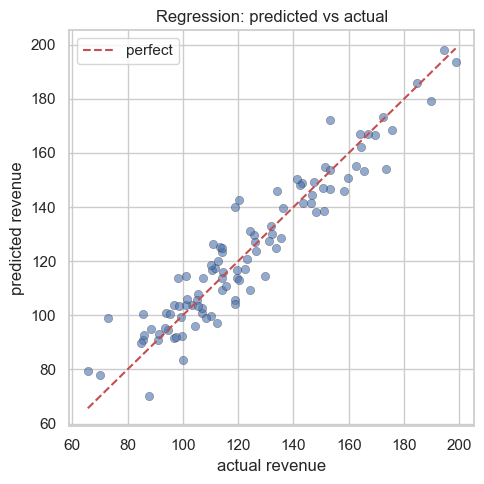

In [11]:
# Build a continuous target: revenue driven by charges, usage, tenure + noise.
rev = (df["monthly_charges"] * 1.4
       + df["avg_usage_gb"] * 0.6
       + df["tenure_months"] * 0.3
       + rng.normal(0, 6, len(df)))
df["revenue"] = rev.round(2)

yr = df["revenue"].to_numpy()
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X, yr, test_size=0.25, random_state=RANDOM_STATE)

reg = make_regressor(model_config=MambularConfig(d_model=64, n_layers=4))
reg.fit(Xr_train, yr_train, max_epochs=EPOCHS, lr=1e-4)
yhat = reg.predict(Xr_test)

print(f"Backend: {backend}")
print(f"MAE : {mean_absolute_error(yr_test, yhat):.2f}")
print(f"R²  : {r2_score(yr_test, yhat):.3f}")

plt.figure(figsize=(5, 5))
plt.scatter(yr_test, yhat, alpha=0.6, edgecolor="k", linewidth=0.3)
lims = [min(yr_test.min(), yhat.min()), max(yr_test.max(), yhat.max())]
plt.plot(lims, lims, "r--", label="perfect")
plt.xlabel("actual revenue"); plt.ylabel("predicted revenue")
plt.title("Regression: predicted vs actual"); plt.legend()
plt.tight_layout(); plt.show()

## 5. Distributional regression (LSS) with `MambularLSS`

Here is a job the trusty drill simply cannot do — a true specialist tool. This is where deep tabular models do something trees can't do out of the box. **LSS = Location, Scale, Shape.** Instead of a single point prediction, the model outputs the *parameters of a probability distribution* for each row — so you get **uncertainty for free**.

```python
from deeptab.models import MambularLSS
from deeptab.configs import MambularConfig

lss = MambularLSS(model_config=MambularConfig(d_model=64, n_layers=8, dropout=0.2))
lss.fit(X_train, y_train, max_epochs=150, lr=1e-4, patience=10, family='normal')
```

The **`family`** argument — a `.fit()` parameter in v2 — picks the distribution: `'normal'`, `'poisson'` (counts), `'gamma'` (positive, skewed — claims, durations), `'beta'` (rates in 0–1), `'studentt'` (heavy tails), `'tweedie'`, and more.

### Why a distribution beats a point estimate

Back to our running example: a point forecast of '€120 revenue' for a customer hides whether the model means *€120 ± 3* or *€120 ± 60*. For real decisions the spread is the whole game:

- **Pricing / risk** — set a margin that covers the *downside tail*, not just the average.
- **Inventory / demand** — stock to a high quantile so you rarely run out; the distribution gives you that quantile directly.
- **Triage** — flag the rows where the model is *uncertain* for human review.

> 🔗 **Complementary tool — conformal prediction (NB A5).** LSS gives a *parametric* uncertainty estimate (it assumes the family is right). **Conformal prediction** wraps *any* model to produce intervals with a *distribution-free finite-sample coverage guarantee*. They pair well: use LSS for a rich shape, conformal to certify calibrated coverage.

In [12]:
lss = make_lss(model_config=MambularConfig(d_model=64, n_layers=8, dropout=0.2))
lss.fit(Xr_train, yr_train, max_epochs=EPOCHS, lr=1e-4, patience=10, family="normal")

# Real DeepTab returns distribution parameters; our stand-in returns (mean, std).
# We normalise both to a (mu, sigma) view for the demo.
if HAS_DEEPTAB:
    # DeepTab LSS .predict yields per-row distribution params; shapes vary by
    # family/version. We defensively coerce to a 2-column (mu, sigma) array.
    raw = np.asarray(lss.predict(Xr_test), dtype=float)
    raw = raw.reshape(len(Xr_test), -1)
    mu = raw[:, 0]
    sigma = np.abs(raw[:, 1]) if raw.shape[1] > 1 else np.full(len(mu), raw[:, 0].std())
else:
    params = lss.predict(Xr_test)
    mu, sigma = params[:, 0], params[:, 1]

print("First 5 rows — predicted distribution (normal):")
for i in range(5):
    lo, hi = mu[i] - 1.96 * sigma[i], mu[i] + 1.96 * sigma[i]
    print(f"  row {i}: mean={mu[i]:7.2f}  sd={sigma[i]:6.2f}  95% interval=[{lo:7.2f}, {hi:7.2f}]")

First 5 rows — predicted distribution (normal):
  row 0: mean= 105.58  sd=  6.47  95% interval=[  92.91,  118.26]
  row 1: mean= 198.13  sd=  6.47  95% interval=[ 185.46,  210.80]
  row 2: mean= 126.36  sd=  6.47  95% interval=[ 113.69,  139.04]
  row 3: mean=  70.03  sd=  6.47  95% interval=[  57.36,   82.71]
  row 4: mean= 103.88  sd=  6.47  95% interval=[  91.21,  116.55]


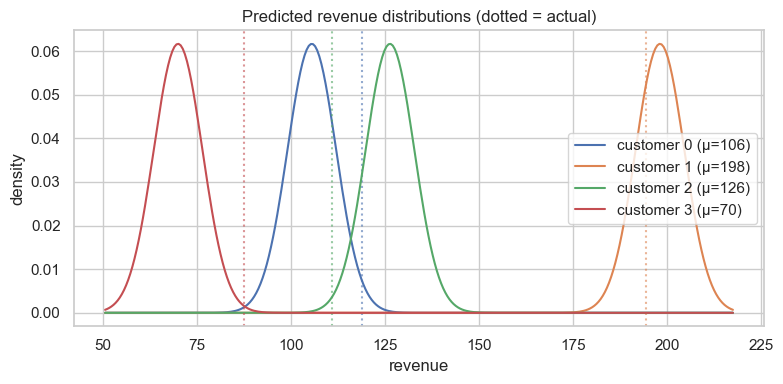

Decision example — stock/price to the 10th percentile (pessimistic):
  mean of point forecasts : 123.63
  mean of 10th-pct forecasts: 115.35  <- the cautious number


In [13]:
# Visualise the predicted distribution for a few customers.
fig, ax = plt.subplots(figsize=(8, 4))
grid = np.linspace(mu.min() - 3 * sigma.max(), mu.max() + 3 * sigma.max(), 300)
for i in range(4):
    pdf = norm.pdf(grid, loc=mu[i], scale=max(sigma[i], 1e-6))
    ax.plot(grid, pdf, label=f"customer {i} (μ={mu[i]:.0f})")
    ax.axvline(yr_test[i], color=ax.lines[-1].get_color(), ls=":", alpha=0.6)
ax.set_title("Predicted revenue distributions (dotted = actual)")
ax.set_xlabel("revenue"); ax.set_ylabel("density"); ax.legend()
plt.tight_layout(); plt.show()

print("Decision example — stock/price to the 10th percentile (pessimistic):")
q10 = mu - 1.2816 * sigma
print(f"  mean of point forecasts : {mu.mean():.2f}")
print(f"  mean of 10th-pct forecasts: {q10.mean():.2f}  <- the cautious number")

---

### ✋ Quick exercise (~2 min) — Stock to the 90th percentile

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

The cell above computed a cautious 10th-percentile (`q10`) forecast. Inventory wants the opposite tail: a *high* quantile they'll rarely exceed. From the LSS `mu` and `sigma`, compute the **90th-percentile** revenue forecast per customer and print its mean alongside the mean point forecast.

```python
z90 = 1.2816   # z-score for the 90th percentile of a normal
```

In [14]:
# ✍️ Your turn 👇
z90 = 1.2816   # z-score for the 90th percentile of a normal
# mu and sigma are the per-customer LSS predictions from the cell above.
# q90 = ...                    # 90th-percentile revenue forecast per customer
# print the mean point forecast and the mean 90th-pct forecast


<details>
<summary>✅ <b>Solution</b></summary>

```python
z90 = 1.2816
q90 = mu + z90 * sigma             # or: norm.ppf(0.90, loc=mu, scale=sigma)
print("mean point forecast :", round(mu.mean(), 2))
print("mean 90th-pct forecast:", round(q90.mean(), 2))
```

The 90th-percentile forecast sits ~1.28σ *above* the mean — the optimistic "we'll rarely undershoot demand" number, the mirror image of the cautious 10th-percentile `q10` shown above.
</details>

## 6. Latent embeddings via `model.encode(X)`

A trained deep tabular model has learned, in its hidden layers, a dense vector representation of each row. `model.encode(X)` exposes it:

```python
latent = model.encode(X_test)   # shape (n_rows, d_model-ish)
```

What is it good for?

- **Downstream models** — feed the embedding to a simple, fast model (logistic regression, k-NN) instead of the raw columns.
- **Similarity / retrieval** — nearest neighbours in embedding space = 'customers like this one'.
- **Clustering & visualisation** — segment the embedding space.
- **Transfer** — embeddings from a model trained on a big table can seed a smaller task.

Below we encode the churn data and train a plain logistic regression on the embeddings — a cheap way to reuse the deep model's learned features.

Embedding shape — train: (300, 64), test: (100, 64)
Logistic regression on embeddings — accuracy: 0.780


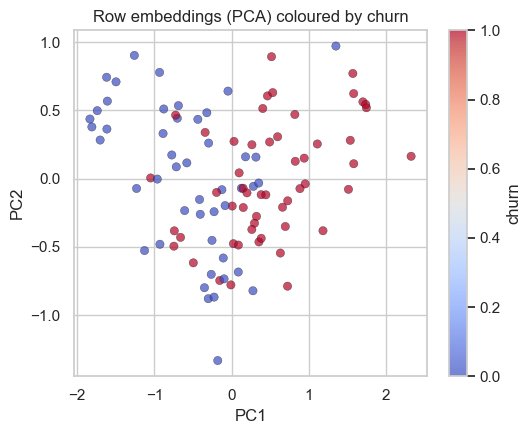

In [15]:
from sklearn.linear_model import LogisticRegression

Z_train = np.asarray(clf.encode(X_train), dtype=float)
Z_test  = np.asarray(clf.encode(X_test), dtype=float)
print(f"Embedding shape — train: {Z_train.shape}, test: {Z_test.shape}")

# Downstream: a tiny linear model on top of the learned representation.
head = LogisticRegression(max_iter=1000)
head.fit(Z_train, y_train)
head_acc = accuracy_score(y_test, head.predict(Z_test))
print(f"Logistic regression on embeddings — accuracy: {head_acc:.3f}")

# Visualise the embedding in 2D (PCA) coloured by churn.
from sklearn.decomposition import PCA
if Z_test.shape[1] >= 2:
    emb2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Z_test)
    plt.figure(figsize=(5.5, 4.5))
    sc = plt.scatter(emb2d[:, 0], emb2d[:, 1], c=y_test, cmap="coolwarm",
                     alpha=0.7, edgecolor="k", linewidth=0.3)
    plt.title("Row embeddings (PCA) coloured by churn")
    plt.xlabel("PC1"); plt.ylabel("PC2"); plt.colorbar(sc, label="churn")
    plt.tight_layout(); plt.show()
else:
    print("Embedding too narrow to plot in 2D (stand-in geometry).")

---

### ✋ Quick exercise (~2 min) — Find the most similar customer

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

"Customers like this one" is just a nearest neighbour in embedding space. Using the `Z_test` embeddings from `clf.encode()`, find the index of the test customer most similar to row `0` by Euclidean distance — excluding row 0 itself.

In [16]:
# ✍️ Your turn 👇
# Z_test holds one embedding row per test customer (from clf.encode above).
# dists = Euclidean distance from Z_test[0] to every row of Z_test
# remember to exclude the row itself, then print the nearest customer's index


<details>
<summary>✅ <b>Solution</b></summary>

```python
dists = np.linalg.norm(Z_test - Z_test[0], axis=1)
dists[0] = np.inf                       # exclude the row itself
nn = int(np.argmin(dists))
print("most similar to customer 0:", nn, "| distance:", round(dists[nn], 3))
```

Smallest distance in embedding space = "the customer most like this one" — the core of similarity search and segmentation built straight on `.encode()` output, no extra training.
</details>

## 7. Hyperparameter tuning

Two complementary routes.

### a) Built-in Bayesian search — `model.optimize_hparams`

DeepTab ships its own tuner that knows each architecture's sensible search space and uses Bayesian optimisation (via `scikit-optimize`):

```python
model = MambularClassifier()
best = model.optimize_hparams(X_train, y_train, time=20)  # mutates model.config; returns best hparams
model.fit(X_train, y_train)                                # refit with the tuned config
```

`optimize_hparams` runs `time` trials, updates `model.config` in place with the winner, and **returns the best hyperparameters** (a list, *not* a fitted model) — so refit once afterwards. This is the quickest way to a strong model: no search space to hand-design.

### b) sklearn `RandomizedSearchCV` — full ecosystem integration

Because DeepTab models are real `BaseEstimator`s, every sklearn tuning tool works, with cross-validation and any scorer. In v2 the tunable knobs live on the config objects, so pass config *instances* and tune their **nested** params with sklearn's `obj__param` syntax:

```python
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'model_config__d_model': randint(32, 128),
    'model_config__n_layers': randint(2, 10),
    'preprocessing_config__numerical_preprocessing': ['ple', 'standardization'],
}
base = MambularClassifier(model_config=MambularConfig(),
                          preprocessing_config=PreprocessingConfig())
rs = RandomizedSearchCV(base, param_dist, n_iter=10, cv=3, scoring='accuracy')
rs.fit(X_train, y_train, max_epochs=5, rebuild=False)
```

> The `rebuild=False` fit kwarg tells DeepTab to reuse the preprocessing pipeline across CV folds instead of rebuilding it each time — a big speed-up during search. (`max_epochs=5` keeps each fit short while searching.)

In [17]:
# (a) Built-in tuner. On real DeepTab this runs a scikit-optimize Bayesian
# search that mutates model.config IN PLACE and RETURNS the best hyperparameters
# (a list) — not a fitted model — so we refit once afterwards with the tuned
# config. The stand-in mirrors that return contract (no real search). We keep
# the trial budget (`time`) small so the demo stays quick when DeepTab is real.
tuned = make_classifier()
best_hparams = tuned.optimize_hparams(X_train, y_train, time=10, max_epochs=EPOCHS)
tuned.fit(X_train, y_train, max_epochs=EPOCHS)   # refit with the tuned config

print(f"Best hyperparameters: {best_hparams}")
print(f"Tuned accuracy: {accuracy_score(y_test, tuned.predict(X_test)):.3f}")

   [stand-in] optimize_hparams is a no-op (no real search).
Best hyperparameters: [64, 4]
Tuned accuracy: 0.780


In [18]:
# (b) RandomizedSearchCV — works on both backends. In v2 the tunable knobs
# live on the config objects, so we pass config *instances* to the estimator and
# tune their NESTED params via sklearn's `obj__param` syntax.
param_dist = {
    "model_config__d_model": randint(32, 128),
    "model_config__n_layers": randint(2, 6),
    "preprocessing_config__numerical_preprocessing": ["ple", "standardization"],
}
base = make_classifier(model_config=MambularConfig(),
                       preprocessing_config=PreprocessingConfig())

# fit kwargs differ: real DeepTab accepts max_epochs/rebuild; the stand-in
# ignores unknown kwargs gracefully, so we pass them either way.
fit_params = {"max_epochs": EPOCHS, "rebuild": False} if HAS_DEEPTAB else {}

rs = RandomizedSearchCV(base, param_dist, n_iter=4, cv=3,
                        scoring="accuracy", random_state=RANDOM_STATE)
rs.fit(X_train, y_train, **fit_params)

print(f"Best CV accuracy : {rs.best_score_:.3f}")
print(f"Best params      : {rs.best_params_}")
print(f"Test accuracy    : {accuracy_score(y_test, rs.predict(X_test)):.3f}")

Best CV accuracy : 0.757
Best params      : {'model_config__d_model': 83, 'model_config__n_layers': 2, 'preprocessing_config__numerical_preprocessing': 'ple'}
Test accuracy    : 0.700


## 🧪 Exercises

These are best done with **real DeepTab installed** (`pip install deeptab`), but the offline stand-in lets you draft and run the *code shape* first.

1. **Architecture bake-off.** Loop over `['Mambular', 'FTTransformer', 'ResNet', 'TabM']`, train each classifier on the churn data, and tabulate accuracy + ROC-AUC + train time. Does any deep model beat the `HistGradientBoosting` baseline here? Why might it not, on 400 rows?
2. **Bigger data.** Regenerate the dataset with `N = 50_000`. Re-run the deep model vs the tree. Does the gap change? This is the 'DL likes scale' lesson in miniature.
3. **Pick the right family.** Build a *count* target (e.g. number of support tickets next month) and fit `MambularLSS` with `family='poisson'` (the family is a `.fit()` argument in v2). Compare the predicted intervals to a `family='normal'` fit. Which respects 'counts can't be negative'?
4. **Embeddings for retrieval.** Use `.encode()` plus `sklearn`'s `NearestNeighbors` to build a 'find me 5 similar customers' function.
5. **Tune for real.** Run `RandomizedSearchCV` with `scoring='roc_auc'` and a wider `n_layers` range. Compare its winner to `optimize_hparams`.
6. **Conformal pairing (stretch).** Revisit **NB A5** and wrap your trained regressor in a split-conformal procedure. Compare conformal interval width to the LSS `±1.96σ` interval — which is wider, and which has a coverage *guarantee*?

## 🧠 Key takeaways

We put one customer-churn table on the workbench and reached for several tools through **one socket** — and the most-used tool was still the trusty drill:

- **Trees first — grab the drill.** Gradient boosting (XGBoost/LightGBM/HistGB) is the right default for most tabular problems. Benchmark it before adopting deep learning. (On our 400-row churn table the neural side — here the offline MLP stand-in — actually nosed ahead of it, 0.848 vs 0.807 test AUC; that is one split of 100 test rows, i.e. noise, and the *discipline* of benchmarking the tree first is the part that transfers.)
- **DeepTab = sklearn API over 15 tabular DL architectures.** One socket, many power tools: every model is a `<Name>Classifier` / `<Name>Regressor` / `<Name>LSS`; swap architectures by changing one class name.
- **Where DL earns its place** (when a specialist tool beats the drill): large data, multimodal inputs, distributional outputs, reusable embeddings, transfer learning.
- **LSS (distributional regression)** predicts a whole distribution — mean *and* uncertainty — the job trees can't do natively. Pair it with **conformal prediction (NB A5)** for guaranteed coverage.
- **`.encode()`** turns the model into a feature extractor: dense row embeddings for downstream models, similarity search, and clustering.
- **Tuning** is easy two ways: built-in `optimize_hparams` (Bayesian, zero-config) or any sklearn searcher like `RandomizedSearchCV`.
- **`numerical_preprocessing='ple'`** (piecewise-linear encoding) is a strong default for numeric columns; PreTab auto-detects numeric vs categorical straight from your DataFrame.
- This notebook ran **offline** on a stand-in — the *API and reasoning* transfer directly to the real library once installed.


## ✅ Self-assessment

- [ ] Explain *why* deep learning on tabular data, and where DeepTab sits next to gradient boosting
- [ ] Train a DeepTab classifier/regressor behind the familiar **scikit-learn API** (`fit`/`predict`)
- [ ] Configure a model with the **v2 split-config API** (`MambularConfig` / `PreprocessingConfig` / `TrainerConfig`)
- [ ] Extract learned **embeddings** with `.encode()` for a downstream model
- [ ] Tune hyperparameters (`optimize_hparams` / `RandomizedSearchCV`) and read the offline stand-in's limits


## 🚀 Next step

You've reached the end of the optional Module 12 — and, with it, the modelled tour of the course's tabular and deep-learning toolkit.

- **Install it for real:** `pip install deeptab`, then re-run this notebook. Watch the stand-in messages disappear and the genuine Mamba / Transformer models take over.
- **Compare back to the core ML modules** — NB 17 (sklearn), NB 19 (feature engineering), NB A5 (conformal prediction) — to keep the GBMs-first instinct sharp.
- **Return to the course [README](../README.md)** for the full map, the capstones (Module 15), and what to build next.

DeepTab is one good entry point into tabular deep learning; the judgement you practised here — *try the simple strong baseline, reach for DL when it buys you something specific* — is the part that lasts. 🎓

---

*Notebook 44 — DeepTab: Deep Learning for Tabular Data · Module 12 (Optional) · Python for AI-Driven Automation and Business Data Science.*